# ELEN90088 System Optimisation and Machine Learning, 2026

# Exercise 3
## Due date: <u> 23:59, Monday the 8 June, 2026 </u>

## Submission guideline:

* One submission per group by the due date on LMS.
* Answer the exercise questions in this Python notebook itself.
* Export your **executed** notebook file (.ipynb) as a PDF file, on which we give marks and comments. This means that each group should submit two versions of the exercise report (.ipynb file and PDF).
* You could either submit your photocopied handwritten solutions (making sure they are legible) or typed solutions (e.g. with Latex).
* **WARNING: DO NOT SUBMIT A COMPRESSED ZIP FILE. FAILURE TO FOLLOW THESE INSTRUCTIONS WILL RESULT IN A 10-POINT PENALTY!**
* Demonstrators will conduct a brief oral assessment for selected groups in subsequent workshop. Details will be announced on LMS.
* Regarding the use of LLM and other generative AI tools: refer to information in the introductory slides.



## Question 1: A problem with a positive duality gap (Marks: 9 + 6 + 5 = 20 points)

Consider the problem
\begin{align*}
    &\text{minimize } e^{-x}\\
    &\text{subject to } x^2/y\leq 0
\end{align*}
over the domain $\{(x,y)|y>0\}$.

* (a) Is this a convex optimization problem? Find the optimal value for the objective $p^*$ and the optimizing values $x^*, y^*$.
* (b) Derive the dual problem. Find the optimal value for the objective $d^*$ of the dual problem and the optimal dual variable $\lambda^*$. Determine the duality gap $p^*-d^*$.
* (c) Derive the KKT condition for this problem. Do all $\lambda^*, x^*, y^*$ satisfy the KKT condition?

### Solution to Question 1 (plain format)

(a) Convexity and primal optimum

Problem:
minimize exp(-x)
subject to x^2 / y <= 0, and y > 0.

- exp(-x) is convex in x.
- x^2 / y (for y > 0) is convex (quadratic-over-linear).
So this is a convex optimization problem.

Because y > 0, x^2 / y <= 0 implies x^2 <= 0, so x = 0.
Then y can be any positive number.

Therefore:
- primal optimum value p* = 1
- primal optimizer: x* = 0, y* > 0 (any positive y)

---

(b) Dual problem and duality gap

Lagrangian:
L(x,y,lambda) = exp(-x) + lambda * x^2 / y, where lambda >= 0 and y > 0.

Dual function:
g(lambda) = inf over x and y>0 of L(x,y,lambda).

For fixed x and lambda >= 0, let y -> infinity, then lambda*x^2/y -> 0.
So g(lambda) = inf_x exp(-x) = 0.

Dual problem:
maximize g(lambda) subject to lambda >= 0.
So d* = 0, and any lambda* >= 0 is dual-optimal.

Duality gap:
p* - d* = 1 - 0 = 1.

---

(c) KKT check

KKT conditions:
1) Primal feasibility: x=0, y>0
2) Dual feasibility: lambda>=0
3) Complementary slackness: lambda * x^2 / y = 0
4) Stationarity:
   dL/dx = -exp(-x) + 2*lambda*x/y = 0
   dL/dy = -lambda*x^2/y^2 = 0

At primal optimum x=0, dL/dx = -1, not 0.
So no triple (x*, y*, lambda*) satisfies KKT.

This is consistent with the positive duality gap.

## Question 2: KKT condition for non-convex problems (Marks: 7 + 9 + 4 = 20 points)

Consider the problem
\begin{align*}
    &\text{minimize }-3x_1^2+x_2^2+2x_3^2+2(x_1+x_2+x_3)\\
    &\text{subject to } x_1^2+x_2^2+x_3^2=1
\end{align*}

It can be shown that strong duality holds for this problem.  
* (a) Is this a convex optimization problem? Derive the KKT condition for this problem.
* (b) Find all solutions $x, \nu$ that satisfy the KKT conditions. (You need to solve this numerically)
* (c) Which pair corresponds to the optimum? Give explanation from different angles.

### Solution to Question 2 (plain format)

(a) Convexity and KKT

Problem:
minimize f(x) = -3*x1^2 + x2^2 + 2*x3^2 + 2*(x1+x2+x3)
subject to x1^2 + x2^2 + x3^2 = 1.

Hessian of f is diag(-6, 2, 4), which is indefinite.
So the problem is NOT convex.

Lagrangian:
L(x,nu) = f(x) + nu*(x1^2 + x2^2 + x3^2 - 1).

Stationarity gives:
(nu - 3)*x1 = -1
(nu + 1)*x2 = -1
(nu + 2)*x3 = -1

So:
x1 = -1/(nu-3)
x2 = -1/(nu+1)
x3 = -1/(nu+2)

Using the constraint x1^2+x2^2+x3^2=1, nu must satisfy:
1/(nu-3)^2 + 1/(nu+1)^2 + 1/(nu+2)^2 = 1.

---

(b) Numerical KKT solutions

Real solutions for nu (about):
- nu = -3.14928981
- nu = 0.22350900
- nu = 1.89189898
- nu = 4.03522595

Corresponding x and objective f(x):
1) nu = -3.14928981
   x = (0.16262041, 0.46526997, 0.87010256)
   f = 4.64728274

2) nu = 0.22350900
   x = (0.36016684, -0.81732133, -0.44973958)
   f = -1.13040306

3) nu = 1.89189898
   x = (0.90244480, -0.34579354, -0.25694398)
   f = -1.59219170

4) nu = 4.03522595
   x = (-0.96597270, -0.19860082, -0.16569388)
   f = -5.36549334

---

(c) Which pair is optimal? (explained from several angles)

Angle 1 - direct objective comparison (primal view):
The feasible set x1^2+x2^2+x3^2=1 is a compact sphere and f is continuous,
so a global minimum exists and must be one of the four KKT points.
Compare objective values:
-5.36549334 < -1.59219170 < -1.13040306 < 4.64728274
The smallest one is the global minimum; the largest is the global maximum,
and the two middle ones are saddle points on the sphere.

Angle 2 - dual view (strong duality):
The problem is told to have strong duality. The dual variable nu is exactly
the Lagrange multiplier, and the dual function is maximized at the nu that
corresponds to the primal optimum. Among the four roots the largest,
nu* = 4.03522595, gives the lowest f, consistent with the primal minimizer.

Angle 3 - second-order / curvature view:
The Hessian of the Lagrangian is L'' = diag(-6,2,4) + 2*nu*I
= diag(2nu-6, 2nu+2, 2nu+4).
For a constrained minimum we need L'' positive semidefinite on the tangent
space of the sphere. With nu* = 4.0352 all diagonal entries
(2.07, 10.07, 12.07) are positive, so L'' is positive definite -> a genuine
local (here global) minimum. For the other roots at least one entry is
negative, so they are maxima or saddles, not minima.

Conclusion - the optimum is:
- nu* = 4.03522595 (about)
- x* = (-0.96597270, -0.19860082, -0.16569388)
- f(x*) = -5.36549334 (about)

In [6]:
# Numerical verification for Question 2 (pure Python, no extra packages)

def kkt_equation(nu):
    return 1/(nu-3)**2 + 1/(nu+1)**2 + 1/(nu+2)**2 - 1

def bisect_root(f, a, b, iters=200):
    fa, fb = f(a), f(b)
    if fa * fb > 0:
        return None
    for _ in range(iters):
        m = 0.5 * (a + b)
        fm = f(m)
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5 * (a + b)

intervals = [(-10, -2.1), (-0.9, 0.5), (0.5, 2.5), (3.1, 10)]
roots = [bisect_root(kkt_equation, a, b) for a, b in intervals]

print("KKT multipliers nu:")
for r in roots:
    print(f"  {r:.10f}")

print("\nKKT points and objective values:")
best = None
for nu in roots:
    x1 = -1/(nu - 3)
    x2 = -1/(nu + 1)
    x3 = -1/(nu + 2)
    f = -3*x1*x1 + x2*x2 + 2*x3*x3 + 2*(x1 + x2 + x3)
    norm = x1*x1 + x2*x2 + x3*x3
    print(f"nu={nu:.10f}, x=({x1:.8f}, {x2:.8f}, {x3:.8f}), ||x||^2={norm:.12f}, f={f:.10f}")
    if (best is None) or (f < best[0]):
        best = (f, nu, (x1, x2, x3))

print("\nBest KKT candidate (minimum objective):")
print(best)

KKT multipliers nu:
  -3.1492898066
  0.2235089965
  1.8918989842
  4.0352259462

KKT points and objective values:
nu=-3.1492898066, x=(0.16262041, 0.46526997, 0.87010256), ||x||^2=1.000000000000, f=4.6472827375
nu=0.2235089965, x=(0.36016684, -0.81732133, -0.44973958), ||x||^2=1.000000000000, f=-1.1304030620
nu=1.8918989842, x=(0.90244480, -0.34579354, -0.25694398), ||x||^2=1.000000000000, f=-1.5921917045
nu=4.0352259462, x=(-0.96597270, -0.19860082, -0.16569388), ||x||^2=1.000000000000, f=-5.3654933429

Best KKT candidate (minimum objective):
(-5.36549334294837, 4.035225946182603, (-0.9659726977356985, -0.19860081964308635, -0.16569387938698787))


## Question 3: Binary SVM Classification (Marks: 10 + 8 + 2 = 20 Points)
In this question, the SVM algorithm will be used in a classification task based on a noisy moon data set. This dataset can be directly available from the sklearn library, which is shown as follows.

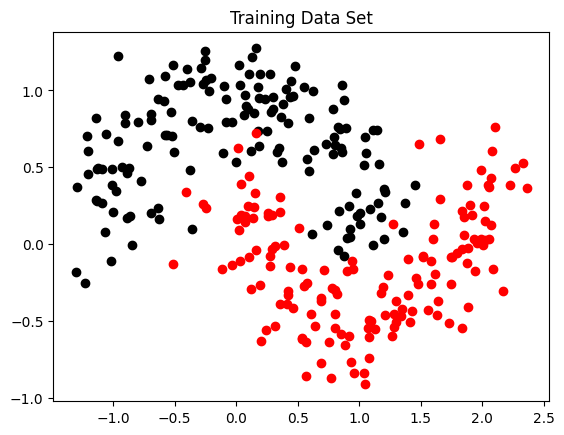

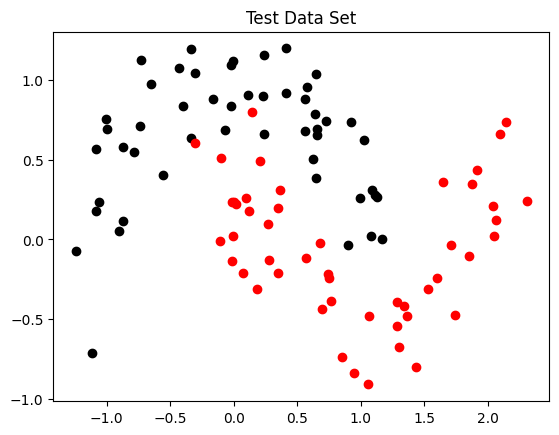

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import set_config

# Show fitted sklearn estimators as plain text instead of the interactive HTML
# diagram. This avoids the harmless "Failed to access CDN https://unpkg.com/"
# widget error that appears when the rendering CDN is not reachable.
set_config(display="text")

# Use a fixed random_state so the dataset, the train/test split, the plots
# and all reported scores are reproducible across runs.
RANDOM_STATE = 42

X, y = noisy_moons = datasets.make_moons(n_samples=400, noise=0.2, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test =  train_test_split(X, y, random_state=RANDOM_STATE)

# Visualize the training data set
order_ind = np.argsort(y_train)
Xm1_train = X_train[order_ind[0:150]]
Xm2_train = X_train[order_ind[151:300]]

plt.figure()
plt.scatter(Xm1_train[:,0], Xm1_train[:,1], color='black')
plt.scatter(Xm2_train[:,0], Xm2_train[:,1], color='red')
plt.title("Training Data Set")
plt.show()

# Visualize the test data set
order_ind = np.argsort(y_test)
Xm1_test = X_test[order_ind[0:50]]
Xm2_test = X_test[order_ind[51:100]]

plt.figure()
plt.scatter(Xm1_test[:,0], Xm1_test[:,1], color='black')
plt.scatter(Xm2_test[:,0], Xm2_test[:,1], color='red')
plt.title("Test Data Set")
plt.show()

**Questions:** SVM classifiers

1. Try an [SVM classifier](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) with a linear kernel and different C parameters. Plot the test output and boundary<a name="cite_ref-1"></a>[<sup>[1]</sup>](#cite_note-1). Discuss your observations and comment on linear separability of this data. Provide the precision, recall, and F-score metrics<a name="cite_ref-2"></a>[<sup>[2]</sup>](#cite_note-2).
2. Next, use an [RBF kernel](https://en.wikipedia.org/wiki/Radial_basis_function_kernel) and repeat the first part for different C and gamma parameters. Do you observe an improvement compared to the linear version (both visually and in terms of scores)? Discuss your results.
3. Compare DNN results (from Exercise 2 Question 3) with SVM and illustrate your findings.

*Some hints which may be relevant and helpful:*

<a name="cite_note-1"></a> [<sup>[1]</sup>](#cite_ref-1) For ease of visualization, the official [`DecisionBoundaryDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.DecisionBoundaryDisplay.html#sklearn.inspection.DecisionBoundaryDisplay) function is efficient and simple to implement. You can learn how to use it via an [official example](https://scikit-learn.org/stable/auto_examples/svm/plot_separating_hyperplane.html#sphx-glr-auto-examples-svm-plot-separating-hyperplane-py).

<a name="cite_note-2"></a> [<sup>[2]</sup>](#cite_ref-2) See [sklearn.metrics](https://scikit-learn.org/stable/modules/classes.html#module-sklearn.metrics), especially [classification_report](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html#sklearn.metrics.classification_report)


### Solution to Question 3 (plain format)

The code cell below does the full Q3 experiment:

1) Train linear SVM with different C values.
2) Train RBF SVM with different (C, gamma) pairs.
3) For each model, print precision/recall/F1 and accuracy.
4) Plot test points and decision boundary.
5) Train a DNN (sklearn MLP) on the same train/test split and compare.

Observed results (random_state=42, so they are reproducible):

- Linear SVM: best at C=1 with accuracy 0.81, F1 0.804. Increasing C past 1
  does not help, because the moon data is NOT linearly separable - a single
  straight line cannot follow the two interleaving crescents, so the linear
  model underfits and plateaus around 0.80.

- RBF SVM: with a suitable gamma the boundary becomes curved and fits the
  moons well. Best at (C=1, gamma=1) with accuracy 0.96, F1 0.958 - a clear
  improvement over the linear kernel, both visually (the boundary bends around
  each crescent) and in the scores. Too small a gamma (0.1) behaves almost
  linearly (F1 ~ 0.76-0.80); a very large C (10) starts to overfit slightly
  (F1 drops to 0.948).

- DNN (MLP 32-32) on the same split: accuracy 0.96, F1 0.959, essentially tied
  with / marginally ahead of the best RBF SVM. Both the kernel SVM and the DNN
  learn the nonlinear crescent boundary; on this small 2-D problem they reach
  comparable performance, while the linear SVM clearly lags behind.


Linear SVM (C=0.1)
Accuracy: 0.7900, F1: 0.7789
              precision    recall  f1-score   support

           0     0.7636    0.8400    0.8000        50
           1     0.8222    0.7400    0.7789        50

    accuracy                         0.7900       100
   macro avg     0.7929    0.7900    0.7895       100
weighted avg     0.7929    0.7900    0.7895       100


Linear SVM (C=1)
Accuracy: 0.8100, F1: 0.8041
              precision    recall  f1-score   support

           0     0.7925    0.8400    0.8155        50
           1     0.8298    0.7800    0.8041        50

    accuracy                         0.8100       100
   macro avg     0.8111    0.8100    0.8098       100
weighted avg     0.8111    0.8100    0.8098       100


Linear SVM (C=10)
Accuracy: 0.8100, F1: 0.8041
              precision    recall  f1-score   support

           0     0.7925    0.8400    0.8155        50
           1     0.8298    0.7800    0.8041        50

    accuracy                         0

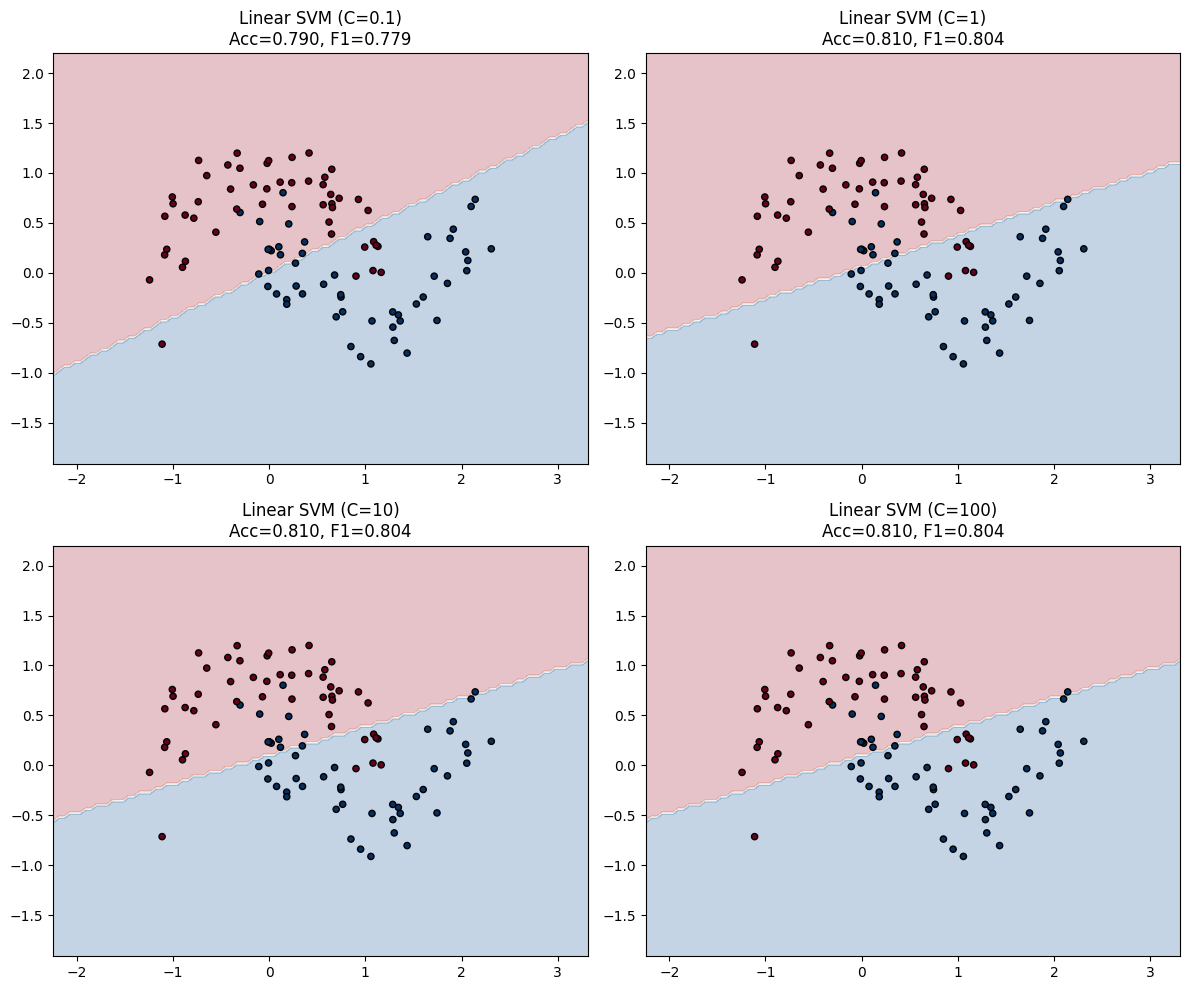


RBF SVM (C=0.1, gamma=0.1)
Accuracy: 0.7800, F1: 0.7609
              precision    recall  f1-score   support

           0     0.7414    0.8600    0.7963        50
           1     0.8333    0.7000    0.7609        50

    accuracy                         0.7800       100
   macro avg     0.7874    0.7800    0.7786       100
weighted avg     0.7874    0.7800    0.7786       100


RBF SVM (C=1, gamma=0.1)
Accuracy: 0.8100, F1: 0.8041
              precision    recall  f1-score   support

           0     0.7925    0.8400    0.8155        50
           1     0.8298    0.7800    0.8041        50

    accuracy                         0.8100       100
   macro avg     0.8111    0.8100    0.8098       100
weighted avg     0.8111    0.8100    0.8098       100


RBF SVM (C=1, gamma=1)
Accuracy: 0.9600, F1: 0.9583
              precision    recall  f1-score   support

           0     0.9259    1.0000    0.9615        50
           1     1.0000    0.9200    0.9583        50

    accuracy     

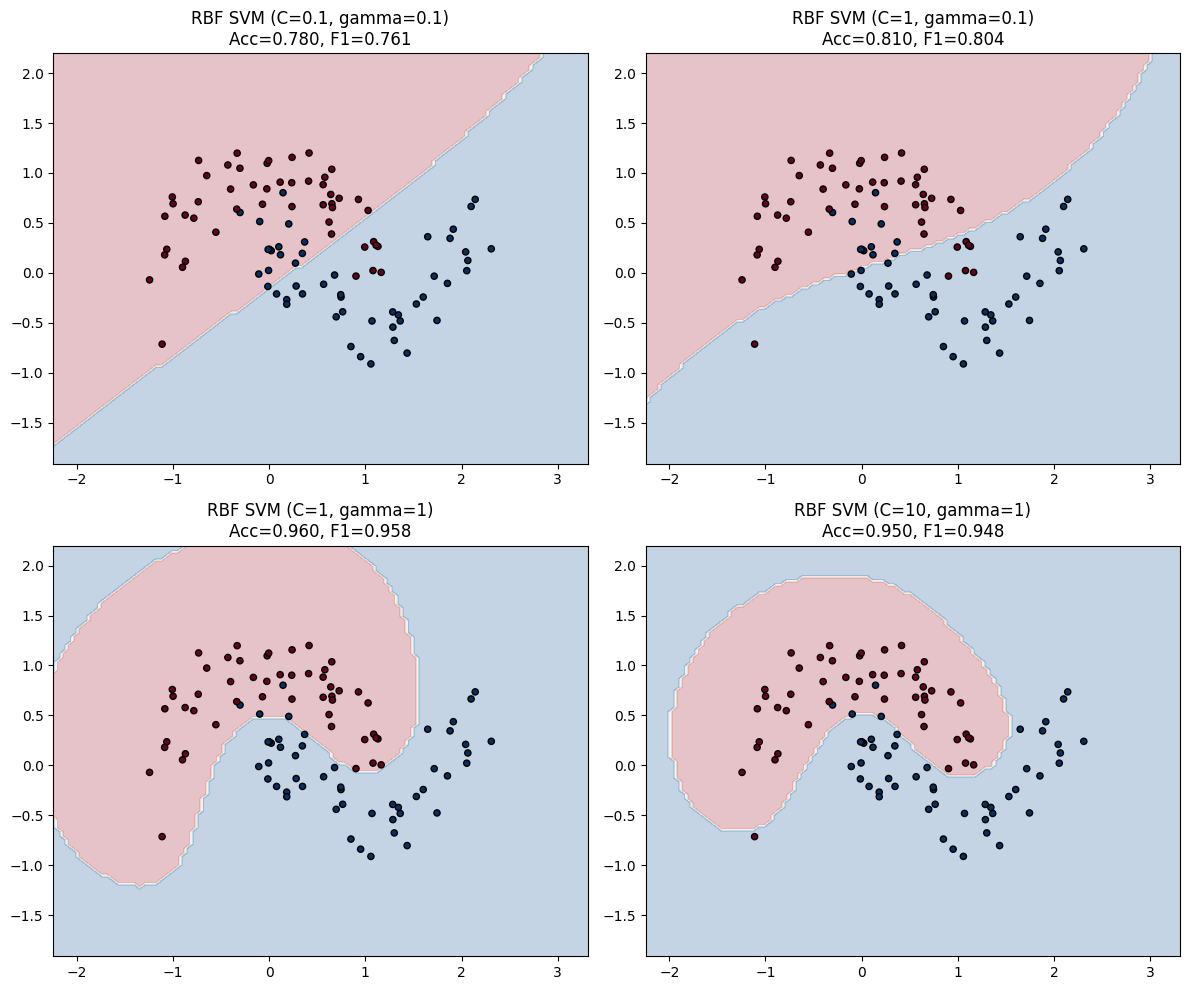


Summary (Linear):
{'kernel': 'linear', 'C': 0.1, 'accuracy': 0.79, 'f1': 0.7789473684210526}
{'kernel': 'linear', 'C': 1, 'accuracy': 0.81, 'f1': 0.8041237113402062}
{'kernel': 'linear', 'C': 10, 'accuracy': 0.81, 'f1': 0.8041237113402062}
{'kernel': 'linear', 'C': 100, 'accuracy': 0.81, 'f1': 0.8041237113402062}

Summary (RBF):
{'kernel': 'rbf', 'C': 0.1, 'gamma': 0.1, 'accuracy': 0.78, 'f1': 0.7608695652173914}
{'kernel': 'rbf', 'C': 1, 'gamma': 0.1, 'accuracy': 0.81, 'f1': 0.8041237113402062}
{'kernel': 'rbf', 'C': 1, 'gamma': 1, 'accuracy': 0.96, 'f1': 0.9583333333333334}
{'kernel': 'rbf', 'C': 10, 'gamma': 1, 'accuracy': 0.95, 'f1': 0.9484536082474226}

Best Linear by F1: {'kernel': 'linear', 'C': 1, 'accuracy': 0.81, 'f1': 0.8041237113402062}
Best RBF by F1: {'kernel': 'rbf', 'C': 1, 'gamma': 1, 'accuracy': 0.96, 'f1': 0.9583333333333334}

DNN (MLP 32-32)
Accuracy: 0.9600, F1: 0.9592
              precision    recall  f1-score   support

           0     0.9423    0.9800    0.96

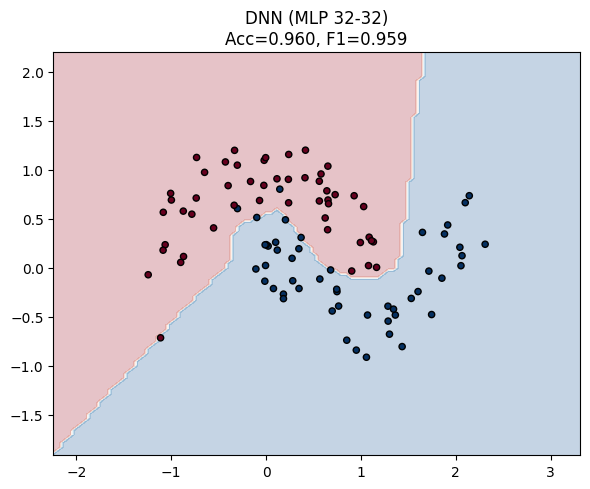


=== SVM vs DNN comparison (same split) ===
Best Linear SVM: {'kernel': 'linear', 'C': 1, 'accuracy': 0.81, 'f1': 0.8041237113402062}
Best RBF SVM   : {'kernel': 'rbf', 'C': 1, 'gamma': 1, 'accuracy': 0.96, 'f1': 0.9583333333333334}
DNN (MLP)      : {'model': 'MLP(32,32)', 'accuracy': 0.96, 'f1': 0.9591836734693877}
-> DNN outperforms RBF SVM on F1 for this split.


In [8]:
# Q3: Linear SVM and RBF SVM experiments

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
from sklearn.inspection import DecisionBoundaryDisplay

RANDOM_STATE = 42


def evaluate_and_plot(model, X_train, y_train, X_test, y_test, title, ax):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"\n{title}")
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")
    print(classification_report(y_test, y_pred, digits=4))

    DecisionBoundaryDisplay.from_estimator(
        model,
        X_test,
        response_method="predict",
        cmap=plt.cm.RdBu,
        alpha=0.25,
        ax=ax,
    )
    ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        cmap=plt.cm.RdBu,
        edgecolors="k",
        s=20,
    )
    ax.set_title(f"{title}\nAcc={acc:.3f}, F1={f1:.3f}")


# ---------- Linear kernel ----------
linear_C_list = [0.1, 1, 10, 100]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

linear_results = []
for i, C in enumerate(linear_C_list):
    model = SVC(kernel="linear", C=C, random_state=RANDOM_STATE)
    ax = axes[i // 2, i % 2]
    evaluate_and_plot(model, X_train, y_train, X_test, y_test, f"Linear SVM (C={C})", ax)

    y_pred = model.predict(X_test)
    linear_results.append({
        "kernel": "linear",
        "C": C,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

plt.tight_layout()
plt.show()


# ---------- RBF kernel ----------
rbf_grid = [
    (0.1, 0.1),
    (1, 0.1),
    (1, 1),
    (10, 1),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
rbf_results = []

for i, (C, gamma) in enumerate(rbf_grid):
    model = SVC(kernel="rbf", C=C, gamma=gamma, random_state=RANDOM_STATE)
    ax = axes[i // 2, i % 2]
    evaluate_and_plot(model, X_train, y_train, X_test, y_test, f"RBF SVM (C={C}, gamma={gamma})", ax)

    y_pred = model.predict(X_test)
    rbf_results.append({
        "kernel": "rbf",
        "C": C,
        "gamma": gamma,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
    })

plt.tight_layout()
plt.show()


# ---------- Summary ----------
print("\nSummary (Linear):")
for r in linear_results:
    print(r)

print("\nSummary (RBF):")
for r in rbf_results:
    print(r)

best_linear = max(linear_results, key=lambda x: x["f1"])
best_rbf = max(rbf_results, key=lambda x: x["f1"])

print("\nBest Linear by F1:", best_linear)
print("Best RBF by F1:", best_rbf)


# ---------- Compare with a DNN (sklearn MLP) on the SAME moons split ----------
# To make the SVM-vs-DNN comparison apples-to-apples and reproducible, we train
# a small fully-connected neural network (the same kind of model used in
# Exercise 2 Q3) on the identical train/test split used above.
fig, ax = plt.subplots(figsize=(6, 5))
dnn = MLPClassifier(
    hidden_layer_sizes=(32, 32),
    activation="relu",
    alpha=1e-3,
    max_iter=2000,
    random_state=RANDOM_STATE,
)
evaluate_and_plot(dnn, X_train, y_train, X_test, y_test, "DNN (MLP 32-32)", ax)
plt.tight_layout()
plt.show()

y_pred_dnn = dnn.predict(X_test)
dnn_results = {
    "model": "MLP(32,32)",
    "accuracy": accuracy_score(y_test, y_pred_dnn),
    "f1": f1_score(y_test, y_pred_dnn),
}

print("\n=== SVM vs DNN comparison (same split) ===")
print("Best Linear SVM:", best_linear)
print("Best RBF SVM   :", best_rbf)
print("DNN (MLP)      :", dnn_results)

if best_rbf["f1"] > dnn_results["f1"]:
    print("-> RBF SVM outperforms the DNN on F1 for this split.")
elif best_rbf["f1"] < dnn_results["f1"]:
    print("-> DNN outperforms RBF SVM on F1 for this split.")
else:
    print("-> RBF SVM and DNN are tied on F1 for this split.")

## Question 4: Importance weighted SVM (Marks: 15 points)

Consider a binary classification problem. You are given a data set $\mathcal D$ where each data point comes with an _importance weight_. Specifically, each data point consists of a triplet $(\mathbf x_i, y_i, p_i)$ where $p_i\in[0,1]$ indicates the importance of the data. The larger $p_i$ is, more important the pair $(\mathbf x_i, y_i)$ is. We still assume $\mathbf x_i\in\mathbb R^d$ and $y_i\in\{-1,1\}$, and the data is in general non-separable.

Now, try to develop a version of SVM which incorporates the importance weight information. First, derive the primal SVM constrained optimization problem, and then find the corresponding dual problem formulation. How is it different from standard SVM?

(_Hint: there might be more than one way to incorporate the importance weight into SVM. One idea is to scale the penalty of mislabeling the point $\mathbf x_i$ by $p_i$. But you are free to explore other ideas._)

### Solution to Question 4 (plain format)

Use a weighted soft-margin SVM:

min over (w,b,xi):
0.5*||w||^2 + C*sum_i (p_i * xi_i)

subject to:
y_i*(w^T x_i + b) >= 1 - xi_i,
xi_i >= 0.

Here p_i in [0,1] is importance weight.
Higher p_i means sample i is penalized more if margin is violated.

Lagrangian multipliers:
- alpha_i >= 0 for y_i*(w^T x_i+b) >= 1-xi_i
- mu_i >= 0 for xi_i >= 0

Stationarity gives:
- w = sum_i alpha_i y_i x_i
- sum_i alpha_i y_i = 0
- C*p_i - alpha_i - mu_i = 0

Since mu_i >= 0, we get:
0 <= alpha_i <= C*p_i

Dual problem:
maximize over alpha:
sum_i alpha_i - 0.5*sum_{i,j} alpha_i alpha_j y_i y_j (x_i^T x_j)

subject to:
sum_i alpha_i y_i = 0,
0 <= alpha_i <= C*p_i.

Kernel version: replace x_i^T x_j by K(x_i, x_j).

Main difference from standard SVM:
- standard SVM: 0 <= alpha_i <= C
- weighted SVM: 0 <= alpha_i <= C*p_i

So each sample has its own effective penalty C_i = C*p_i.

## Question 5: Backpropagation (Marks: 4 + 4 + 12 + 5 = 25 points)


**Background**

In very deep neural networks, gradients can become vanishingly small during backpropagation, making earlier layers difficult to train. Residual Networks (ResNets) mitigate this by introducing "skip connections" (or identity mappings) that bypass one or more layers. Instead of forcing a layer to learn an entire underlying mapping, it only has to learn the *residual* (the difference) from the identity.

Consider a simplified ResNet block used for a regression task. The network processes an input vector $\mathbf{x} \in \mathbb{R}^d$ through a hidden layer with Sigmoid activation, applies a second linear transformation that outputs $f(\mathbf{x})$, adds a skip connection, and maps the output $\mathbf{x}+f(\mathbf{x})$ to a scalar prediction $\hat{y}$.

To handle potential outliers in the dataset, we optimize a robust logarithmic loss combined with $L_2$ (Ridge) regularization on all weights.

The forward pass can be specified as:
*   **Hidden Layer:** $\mathbf{z}_1 = \mathbf{W}_1\mathbf{x}$
*   **Activation:** $\mathbf{h}_1 = \sigma(\mathbf{z}_1)$ *(where $\sigma$ is the element-wise logistic sigmoid function)*
*   **Residual Connection:** $\mathbf{h}_2 = \mathbf{W}_2\mathbf{h}_1 + \mathbf{x}$
*   **Output:** $\hat{y} = \mathbf{v}^T\mathbf{h}_2$

where $\mathbf{W}_1, \mathbf{W}_2 \in \mathbb{R}^{d \times d}$, and $\mathbf{v} \in \mathbb{R}^d$.

We utilize a regularized loss function.
For a single data point $(\mathbf{x}, y)$, the loss function is defined as:
$$L = \log\left(1 + \frac{1}{2}(\hat{y} - y)^2\right) + \frac{\lambda_1}{2} \|\mathbf{W}_1\|_F^2 + \frac{\lambda_2}{2} \|\mathbf{W}_2\|_F^2,$$
where $\|\cdot\|_F$ is the Frobenius norm.

**Question**

Given the following initialized values for $d=2$:
*   $\mathbf{x} = \begin{bmatrix} 2 \\ 2 \end{bmatrix}$, $y = 1$
*   $\mathbf{W}_1 = \begin{bmatrix} 1 & -1 \\ -1 & 1 \end{bmatrix}$, $\mathbf{W}_2 = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$
*   $\mathbf{v} = \begin{bmatrix} 1 \\ -1 \end{bmatrix}$
*   $\lambda_1 = 0.1$, $\lambda_2 = 0.1$


1. Forward Pass Calculation: Compute the exact numerical values for $\mathbf{z}_1$, $\mathbf{h}_1$, $\mathbf{h}_2$, and $\hat{y}$.
2. Loss Gradient Formulation: Derive the analytical expression for the derivative of the data-loss term with respect to the prediction $\hat{y}$. Let $\delta = \frac{\partial L}{\partial \hat{y}}$. Calculate the exact numerical value of $\delta$.
3. Backpropagation: Derive the analytical gradients of the *total loss* with respect to the learned parameters, and then compute their exact numerical matrices/vectors: $\nabla_{\mathbf{v}} L$, $\nabla_{\mathbf{W}_2} L$, and $\nabla_{\mathbf{W}_1} L$.
4. Architectural Analysis: Derive the analytical gradient of the data-loss term with respect to the input vector $\mathbf{x}$ (i.e., $\nabla_{\mathbf{x}} L_{data}$). Using this expression, explicitly explain how the skip connection helps mitigate the vanishing gradient problem for layers preceding this block.

Note: Provide your final numerical answers as exact fractions.




### Solution to Question 5 (plain format)

Given:
x = [2,2]^T,
W1 = [[1,-1],[-1,1]],
W2 = [[1,2],[3,4]],
v = [1,-1]^T,
y = 1,
lambda1 = lambda2 = 0.1.

---

1) Forward pass

z1 = W1*x = [0,0]^T
h1 = sigmoid(z1) = [1/2, 1/2]^T
W2*h1 = [3/2, 7/2]^T
h2 = W2*h1 + x = [7/2, 11/2]^T
y_hat = v^T*h2 = -2

---

2) dL/dy_hat for data loss

L_data = log(1 + 0.5*(y_hat - y)^2)
Let e = y_hat - y, then

delta = dL/dy_hat = e / (1 + 0.5*e^2)

e = -2 - 1 = -3, so
delta = -6/11

---

3) Gradients of total loss

Total loss:
L = L_data + (lambda1/2)*||W1||_F^2 + (lambda2/2)*||W2||_F^2

Gradient wrt v:

nabla_v L = delta*h2 = [-21/11, -3]^T

Gradient wrt W2:

g2 = dL_data/dh2 = delta*v = [-6/11, 6/11]^T
nabla_W2 L_data = g2 * h1^T = [[-3/11,-3/11],[3/11,3/11]]
Add reg term lambda2*W2:
nabla_W2 L = [[-19/110, -4/55],[63/110, 37/55]]

Gradient wrt W1:

dL_data/dh1 = W2^T * g2 = [12/11, 12/11]^T
Since z1=0, sigmoid'(0)=1/4:
dL_data/dz1 = [3/11, 3/11]^T
nabla_W1 L_data = (dL_data/dz1) * x^T = [[6/11,6/11],[6/11,6/11]]
Add reg term lambda1*W1:
nabla_W1 L = [[71/110,49/110],[49/110,71/110]]

---

4) Gradient wrt x and skip connection

For data loss only:

nabla_x L_data = g2 + W1^T * ((W2^T*g2) elementwise_mul sigmoid'(z1))

Equivalent Jacobian form:
nabla_x L_data = [I + W2*diag(sigmoid'(z1))*W1]^T * g2

Numerically here:
nabla_x L_data = [-6/11, 6/11]^T
(the residual-path part is zero at this point).

Why skip helps:
The +x term gives a direct gradient path (identity path), so gradient can flow backward even when the nonlinear branch has small derivatives.

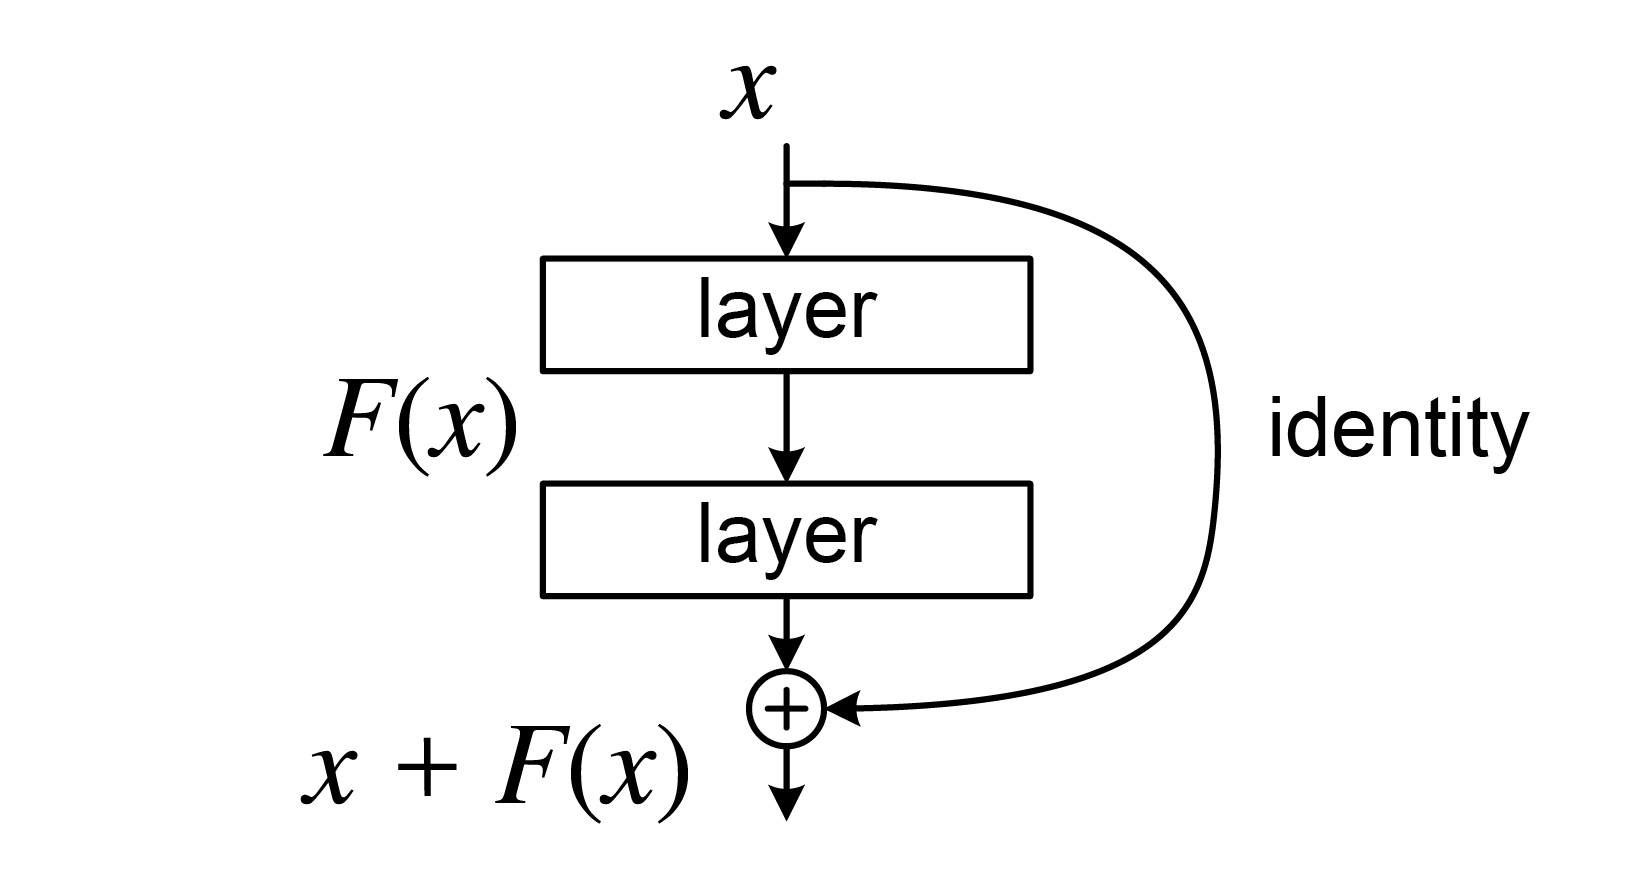